In [ ]:
import pandas as pd 
orders=pd.read_csv("../data/raw/orders.csv")
orders.head()


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [ ]:
import os 
os.listdir("../data/raw")

['aisles.csv',
 'departments.csv',
 'orders.csv',
 'order_products__prior.csv',
 'order_products__train.csv',
 'products.csv']

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


In [ ]:
orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


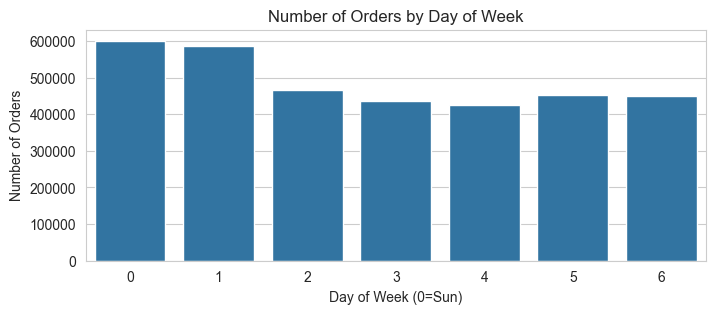

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set_style("whitegrid")
plt.figure(figsize=(8,3))
sns.countplot(x='order_dow',data=orders)
plt.title('Number of Orders by Day of Week')
plt.xlabel('Day of Week (0=Sun)')
plt.ylabel('Number of Orders')
plt.show()

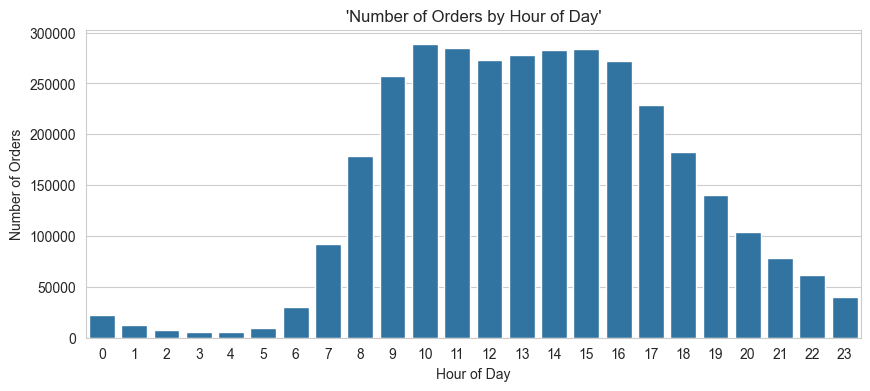

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(10,4))
sns.countplot(x='order_hour_of_day',data=orders)
plt.title("'Number of Orders by Hour of Day'")
plt.xlabel("Hour of Day")
plt.ylabel('Number of Orders') 
plt.show()

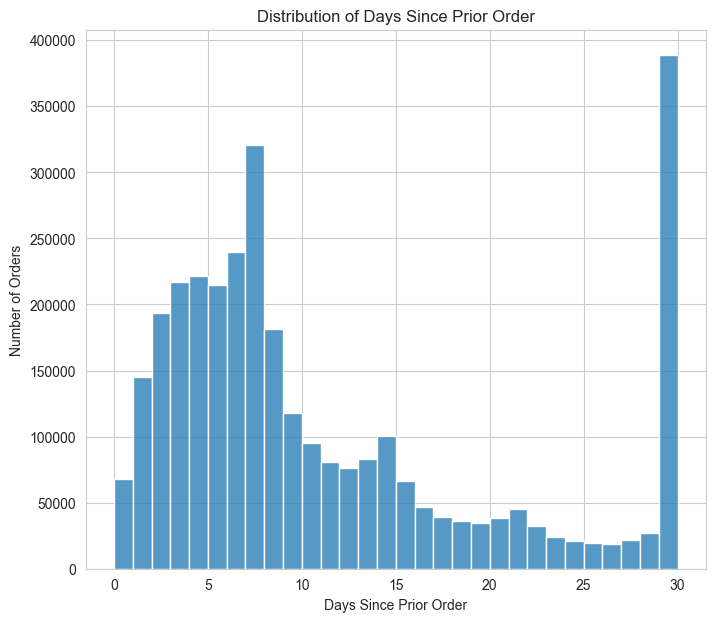

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(8,7))
sns.histplot(orders['days_since_prior_order'].dropna(), bins=30, kde=False)
plt.title("Distribution of Days Since Prior Order")
plt.xlabel('Days Since Prior Order')
plt.ylabel('Number of Orders')
plt.show()

In [ ]:
orders.isnull().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

In [ ]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [ ]:
orders['days_since_prior_order']=orders['days_since_prior_order'].fillna(0)

In [ ]:
orders.isnull().sum()

order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


In [ ]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,0.0
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np 
imputer=SimpleImputer(missing_values=np.nan,strategy='constant', fill_value=0)
orders['days_since_prior_order']=imputer.fit_transform(orders[['days_since_prior_order']])

In [ ]:
orders["order_hour_of_day"]=orders["order_hour_of_day"].astype('category')
orders['order_dow']=orders['order_dow'].astype('category')

In [ ]:
import os 
os.getcwd() 


'c:\\Users\\Hp laptop\\OneDrive\\Documents\\project\\New folder\\notebooks'

In [ ]:
order_products = pd.read_csv("../data/raw/order_products__prior.csv")
products = pd.read_csv("../data/raw/products.csv")
aisles = pd.read_csv("../data/raw/aisles.csv")
departments = pd.read_csv("../data/raw/departments.csv")

In [ ]:
order_products.head()
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [ ]:
orders_merged = pd.merge(
    orders,
    order_products,
    on='order_id',
    how='inner'
)



MemoryError: Unable to allocate 26.1 MiB for an array with shape (3421083,) and data type int64